# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

# load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

In [9]:
# Load the dataset
df = pd.read_csv('data_banknote_authentication.csv')

df.head(10)

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.80730,-0.44699,0
1,4.54590,8.1674,-2.45860,-1.46210,0
2,3.86600,-2.6383,1.92420,0.10645,0
3,3.45660,9.5228,-4.01120,-3.59440,0
4,0.32924,-4.4552,4.57180,-0.98880,0
5,4.36840,9.6718,-3.96060,-3.16250,0
6,3.59120,3.0129,0.72888,0.56421,0
7,2.09220,-6.8100,8.46360,-0.60216,0
8,3.20320,5.7588,-0.75345,-0.61251,0
9,1.53560,9.1772,-2.27180,-0.73535,0


# Explore the data


In [10]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [11]:
# Statistical summary
df.describe()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [13]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check class distribution
print("\nClass distribution:")
print(df['Class'].value_counts())
print(f"\n0 = Fake banknote, 1 = Authentic banknote")

Missing values:
Variance_Wavelet    0
Skewness_Wavelet    0
Curtosis_Wavelet    0
Image_Entropy       0
Class               0
dtype: int64

Class distribution:
Class
0    762
1    610
Name: count, dtype: int64

0 = Fake banknote, 1 = Authentic banknote


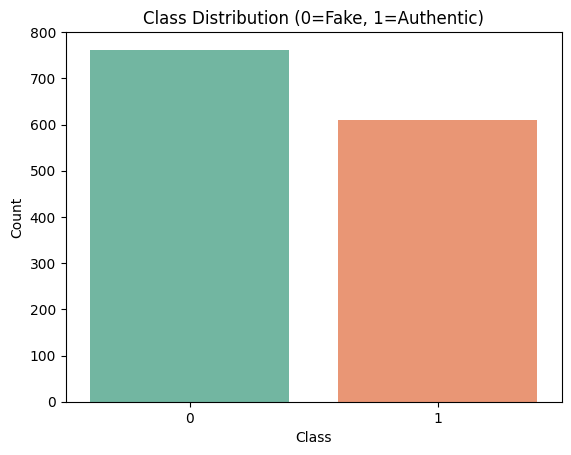

In [15]:
# Visualize class distribution
sns.countplot(x='Class', data=df, palette='Set2')
plt.title('Class Distribution (0=Fake, 1=Authentic)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

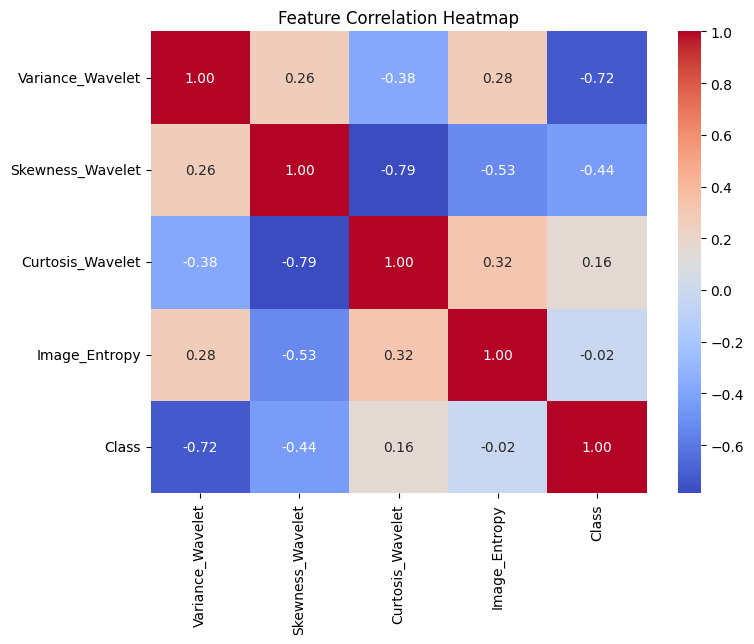

In [16]:
# Feature correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# split

In [18]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 960
Testing samples  : 412


# Decision Tree with GridSearchCV

In [19]:
# Define the parameter grid for Decision Tree
dt_param_grid = {
    'criterion'     : ['gini', 'entropy'],
    'max_depth'     : [None, 3, 5, 10, 15],
    'max_leaf_nodes': [None, 5, 10, 20]
}

# Create base Decision Tree
dt_base = DecisionTreeClassifier(random_state=101)

# GridSearchCV — tries all combinations, picks the best
dt_grid = GridSearchCV(
    estimator=dt_base,
    param_grid=dt_param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='accuracy',
    verbose=1
)

dt_grid.fit(X_train, y_train)

print("\nBest parameters for Decision Tree:")
print(dt_grid.best_params_)
print(f"\nBest cross-validation accuracy: {dt_grid.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best parameters for Decision Tree:
{'criterion': 'entropy', 'max_depth': None, 'max_leaf_nodes': None}

Best cross-validation accuracy: 0.9896


In [20]:
# Get the best Decision Tree model
best_dt = dt_grid.best_estimator_

# Predict on the test set
dt_preds = best_dt.predict(X_test)

# Evaluate the Decision Tree

=== Decision Tree — Confusion Matrix ===


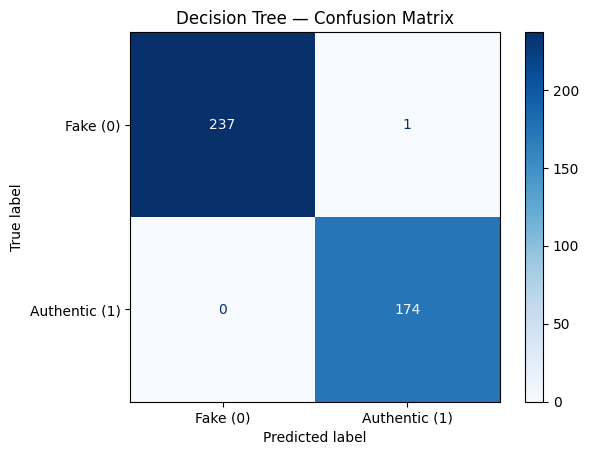

In [21]:
# Confusion Matrix
print("=== Decision Tree — Confusion Matrix ===")
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_preds,
    display_labels=['Fake (0)', 'Authentic (1)'],
    cmap='Blues'
)
plt.title('Decision Tree — Confusion Matrix')
plt.show()

In [22]:
# Classification Report
print("=== Decision Tree — Classification Report ===")
print(classification_report(y_test, dt_preds, target_names=['Fake (0)', 'Authentic (1)']))

=== Decision Tree — Classification Report ===
               precision    recall  f1-score   support

     Fake (0)       1.00      1.00      1.00       238
Authentic (1)       0.99      1.00      1.00       174

     accuracy                           1.00       412
    macro avg       1.00      1.00      1.00       412
 weighted avg       1.00      1.00      1.00       412



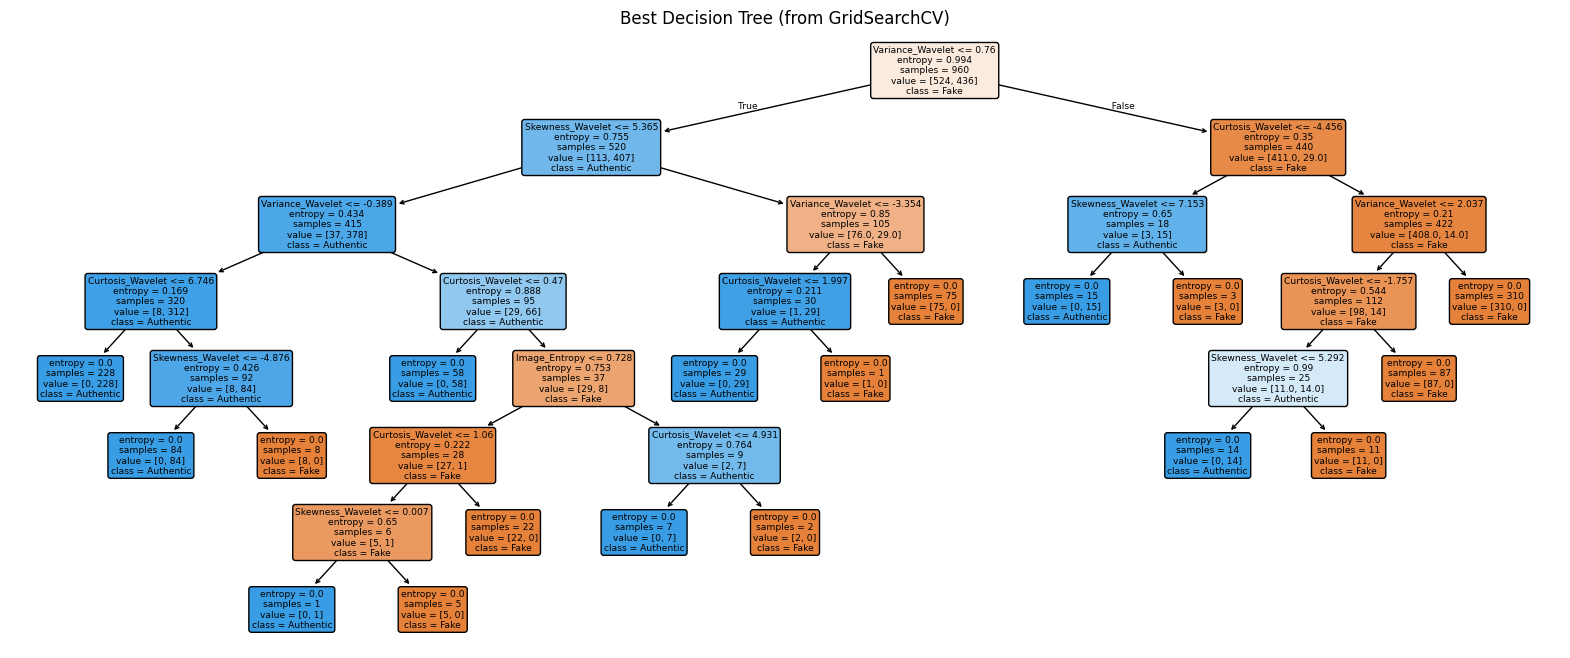

In [23]:
# Visualize the best Decision Tree
plt.figure(figsize=(20, 8), dpi=100)
plot_tree(
    best_dt,
    filled=True,
    feature_names=X.columns,
    class_names=['Fake', 'Authentic'],
    rounded=True
)
plt.title('Best Decision Tree (from GridSearchCV)')
plt.show()

# Random Forest with GridSearchCV

In [24]:
# Define the parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 5, 10, 15],
    'max_features': ['sqrt', 'log2']
}

# Create base Random Forest
rf_base = RandomForestClassifier(random_state=101)

# GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("\nBest parameters for Random Forest:")
print(rf_grid.best_params_)
print(f"\nBest cross-validation accuracy: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters for Random Forest:
{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}

Best cross-validation accuracy: 0.9948


In [25]:
# Get the best Random Forest model
best_rf = rf_grid.best_estimator_

# Predict on the test set
rf_preds = best_rf.predict(X_test)

# Evaluate the Random Forest

=== Random Forest — Confusion Matrix ===


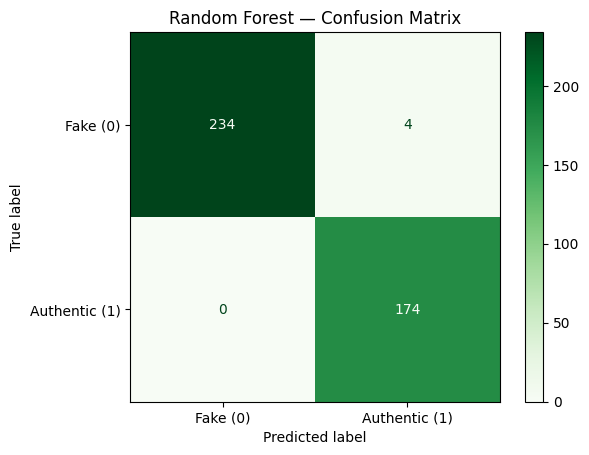

In [26]:
# Confusion Matrix
print("=== Random Forest — Confusion Matrix ===")
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds,
    display_labels=['Fake (0)', 'Authentic (1)'],
    cmap='Greens'
)
plt.title('Random Forest — Confusion Matrix')
plt.show()

In [27]:
# Classification Report
print("=== Random Forest — Classification Report ===")
print(classification_report(y_test, rf_preds, target_names=['Fake (0)', 'Authentic (1)']))

=== Random Forest — Classification Report ===
               precision    recall  f1-score   support

     Fake (0)       1.00      0.98      0.99       238
Authentic (1)       0.98      1.00      0.99       174

     accuracy                           0.99       412
    macro avg       0.99      0.99      0.99       412
 weighted avg       0.99      0.99      0.99       412



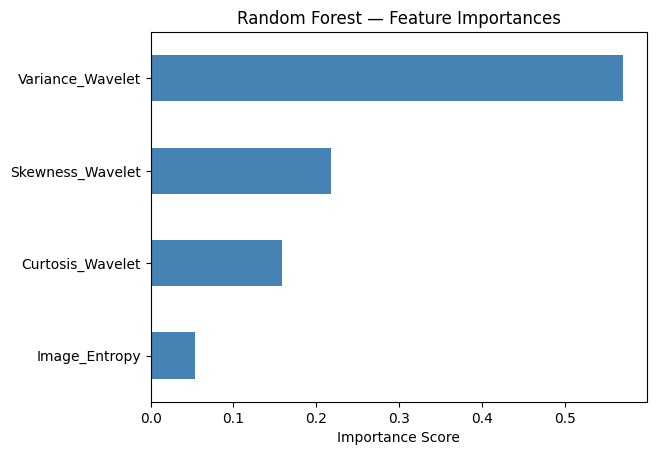

In [28]:
# Feature Importance for Random Forest
feat_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
feat_importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance Score')
plt.show()

# Models comparison 

In [29]:
from sklearn.metrics import accuracy_score

dt_acc  = accuracy_score(y_test, dt_preds)
rf_acc  = accuracy_score(y_test, rf_preds)

comparison = pd.DataFrame({
    'Model'              : ['Decision Tree', 'Random Forest'],
    'Best CV Accuracy'   : [round(dt_grid.best_score_, 4), round(rf_grid.best_score_, 4)],
    'Test Accuracy'      : [round(dt_acc, 4), round(rf_acc, 4)],
    'Best Parameters'    : [str(dt_grid.best_params_), str(rf_grid.best_params_)]
})

print(comparison.to_string(index=False))

        Model  Best CV Accuracy  Test Accuracy                                                     Best Parameters
Decision Tree            0.9896         0.9976 {'criterion': 'entropy', 'max_depth': None, 'max_leaf_nodes': None}
Random Forest            0.9948         0.9903     {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}


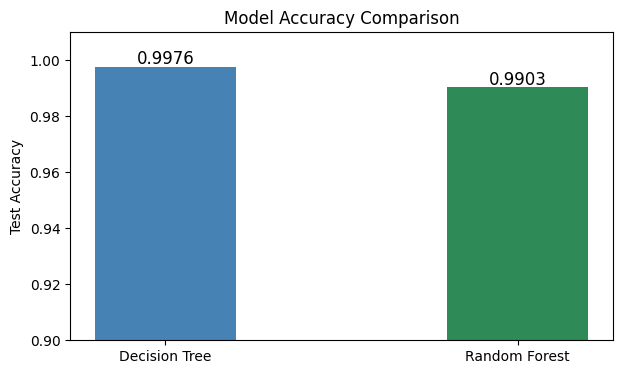

In [30]:
# Bar chart comparison
models     = ['Decision Tree', 'Random Forest']
accuracies = [dt_acc, rf_acc]

plt.figure(figsize=(7, 4))
bars = plt.bar(models, accuracies, color=['steelblue', 'seagreen'], width=0.4)
plt.ylim(0.9, 1.01)
plt.ylabel('Test Accuracy')
plt.title('Model Accuracy Comparison')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{acc:.4f}', ha='center', fontsize=12)
plt.show()

Both models performed exceptionally well, with accuracy above 99%.

The Decision Tree achieved slightly higher test accuracy (99.76%) vs 
Random Forest (99.03%), but this is likely due to the banknote dataset 
being highly separable — meaning a single tree can already find near-
perfect boundaries. The Decision Tree's best params (no depth limit) 
suggest it fully memorized the training data and got lucky on this 
particular test split.

Random Forest's cross-validation accuracy (99.48%) was actually higher 
than the Decision Tree's (98.96%), meaning Random Forest is the more 
RELIABLE and STABLE model. CV accuracy is more trustworthy than a 
single test split because it averages over 5 different evaluations.

For a real banknote detection system, Random Forest would be preferred 
because it is more robust and less dependent on a lucky data split.